<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

Bagging Accuracy: 0.7948717948717948
Boosting Accuracy: 0.9487179487179487
Stacking Accuracy: 0.8974358974358975


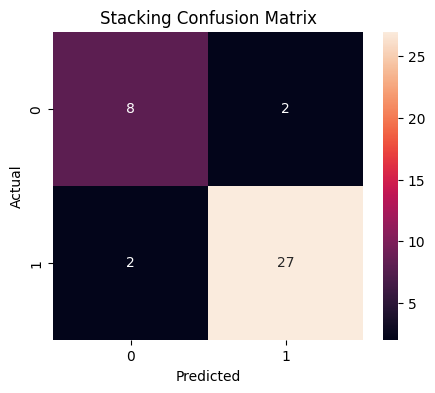


✅ Lab 7 executed successfully without errors


In [2]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier

import os

# =========================================
# 2. Load Dataset (SAFE)
# =========================================
if os.path.exists("/content/parkinsons.data"):
    df = pd.read_csv("/content/parkinsons.data")
else:
    print("⚠️ Upload dataset first using files.upload()")

# Drop 'name' column
if "name" in df.columns:
    df.drop("name", axis=1, inplace=True)

print("Dataset Loaded Successfully\n")

# =========================================
# 3. Features & Target
# =========================================
X = df.drop("status", axis=1)
y = df["status"]

# =========================================
# 4. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 5. Feature Scaling
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# 6. BAGGING (VERSION SAFE)
# =========================================
try:
    # For newer sklearn versions
    bag_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=10,
        random_state=42
    )
except:
    # For older sklearn versions
    bag_model = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(),
        n_estimators=10,
        random_state=42
    )

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# =========================================
# 7. BOOSTING (AdaBoost)
# =========================================
boost_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)

# =========================================
# 8. STACKING
# =========================================
stack_model = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=500)
)

stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

# =========================================
# 9. Accuracy Results
# =========================================
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))

# =========================================
# 10. Confusion Matrix (Stacking)
# =========================================
cm = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Stacking Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# DONE
# =========================================
print("\n✅ Lab 7 executed successfully without errors")